# Training on train.csv, 4 labels, 10 epochs, batch size 32
# 14/04/2025 16:39

In [3]:
# Initialize Paths
from pathlib import Path

current_dir = Path.cwd()
project_root = current_dir.parent
metrics_path = project_root / 'src' / 'models' / 'llm' / 'multi-task-disaster-classifier' /'metrics'

In [38]:
# Load metrics for each epoch
import json

eval_logs = []
for file in metrics_path.iterdir():
    if file:
        with open(file, 'r') as f:
            data = json.load(f)
            eval_logs.append(data)

eval_logs.sort(key= lambda x: x['epoch'])

# View sorted data after loading
import pandas as pd
df = pd.DataFrame(eval_logs)
df.head(10)

,eval_loss,eval_sentiment_accuracy,eval_event_type_accuracy,eval_event_detail_accuracy,eval_label_accuracy,eval_avg_accuracy,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,2.270545,0.883683,0.876387,0.868475,0.646270,0.818704,51.9385,374.751,23.432,1.0
1,1.774036,0.891389,0.899558,0.892057,0.712803,0.848952,51.5889,377.290,23.590,2.0
2,1.642954,0.900277,0.903411,0.897965,0.731710,0.858341,51.6476,376.862,23.564,3.0
3,1.649119,0.896887,0.905723,0.898017,0.733970,0.858649,51.3743,378.867,23.689,4.0
4,1.712478,0.901099,0.905672,0.898068,0.735923,0.860191,50.5734,384.867,24.064,5.0
5,1.772406,0.902744,0.907059,0.900072,0.739262,0.862284,52.3549,371.770,23.245,6.0
6,1.827767,0.901665,0.906956,0.900534,0.742704,0.862965,51.5241,377.765,23.620,7.0


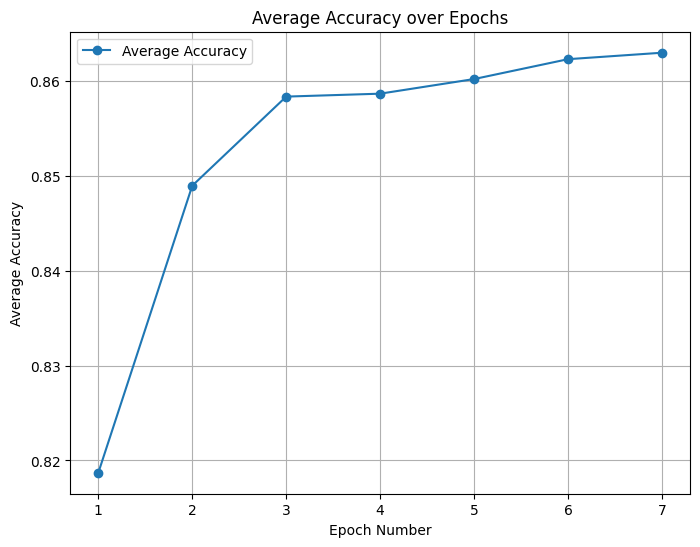

In [39]:
# Plot average accuracy against epochs
import matplotlib.pyplot as plt

# Extract epoch numbers and sentiment accuracies
epochs = [log['epoch'] for log in eval_logs]
average_accuracies = [log['eval_avg_accuracy'] for log in eval_logs]

# Plot sentiment accuracy over epochs
plt.figure(figsize=(8, 6))
plt.plot(epochs, average_accuracies, marker='o', linestyle='-', label='Average Accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Average Accuracy')
plt.title('Average Accuracy over Epochs')
plt.xticks(epochs)  # Show all epoch points on x-axis
plt.legend()
plt.grid(True)
plt.show()

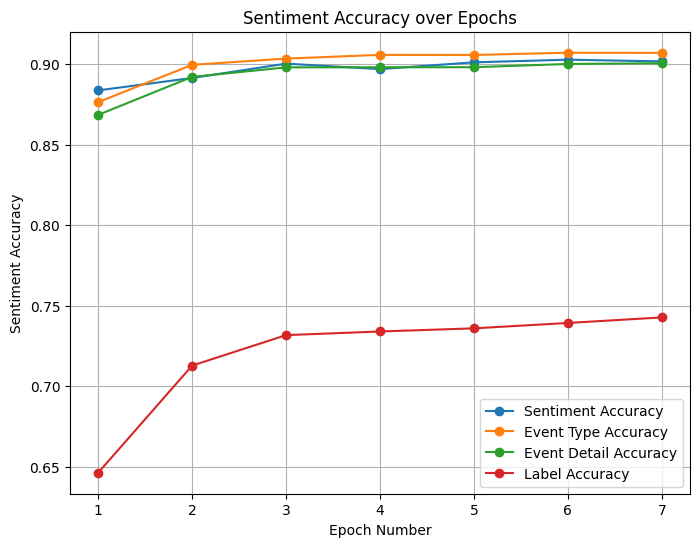

In [40]:
# Plot sentiment accuracy against epochs
import matplotlib.pyplot as plt

# Extract epoch numbers and sentiment accuracies
epochs = [log['epoch'] for log in eval_logs]
sentiment_accuracies = [log['eval_sentiment_accuracy'] for log in eval_logs]
event_type_accuracies = [log['eval_event_type_accuracy'] for log in eval_logs]
event_detail_accuracies = [log['eval_event_detail_accuracy'] for log in eval_logs]
label_accuracies = [log['eval_label_accuracy'] for log in eval_logs]

# Plot sentiment accuracy over epochs
plt.figure(figsize=(8, 6))
plt.plot(epochs, sentiment_accuracies, marker='o', linestyle='-', label='Sentiment Accuracy')
plt.plot(epochs, event_type_accuracies, marker='o', linestyle='-', label='Event Type Accuracy')
plt.plot(epochs, event_detail_accuracies, marker='o', linestyle='-', label='Event Detail Accuracy')
plt.plot(epochs, label_accuracies, marker='o', linestyle='-', label='Label Accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Sentiment Accuracy')
plt.title('Sentiment Accuracy over Epochs')
plt.xticks(epochs)  # Show all epoch points on x-axis
plt.legend()
plt.grid(True)
plt.show()

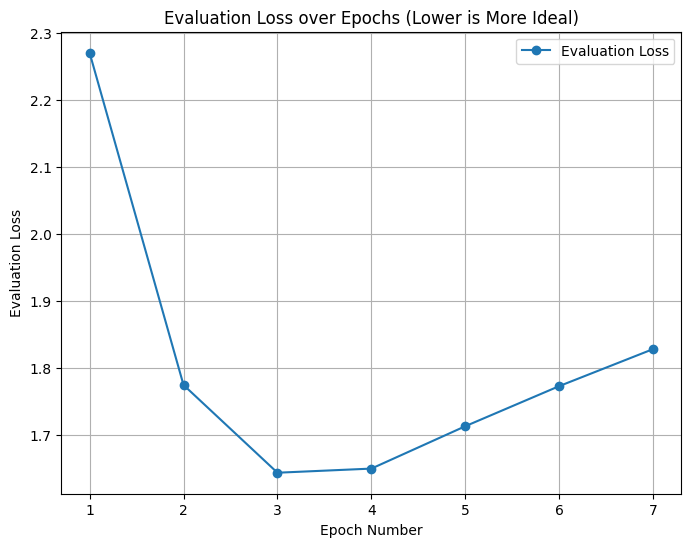

In [41]:
# Plot entropy loss against epochs
import matplotlib.pyplot as plt

# Extract epoch numbers and sentiment accuracies
epochs = [log['epoch'] for log in eval_logs]
entropy_loss = [log['eval_loss'] for log in eval_logs]

# Plot sentiment accuracy over epochs
plt.figure(figsize=(8, 6))
plt.plot(epochs, entropy_loss, marker='o', linestyle='-', label='Evaluation Loss')
plt.xlabel('Epoch Number')
plt.ylabel('Evaluation Loss')
plt.title('Evaluation Loss over Epochs (Lower is More Ideal)')
plt.xticks(epochs)  # Show all epoch points on x-axis
plt.legend()
plt.grid(True)
plt.show()